<a href="https://colab.research.google.com/github/MNawfal24/MachineLearning/blob/main/Minggu4/MNawfalMA_JS04_T1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# 1. Gunakan data 'Mall_Customers.csv'
df_mall = pd.read_csv('/content/drive/MyDrive/ML/Mall_Customers.csv')
display(df_mall.head())

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


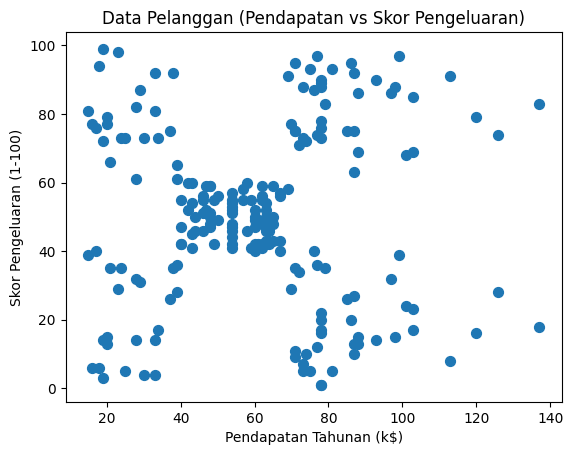

In [3]:
# 2. Tentukan fitur apa yang tepat untuk melakukan clustering (minimal 2)
# Mengambil kolom 'Annual Income (k$)' (indeks 3) dan 'Spending Score (1-100)' (indeks 4)
X_mall = df_mall.iloc[:, [3, 4]].values

# Visualisasi data awal
plt.scatter(X_mall[:, 0], X_mall[:, 1], s=50)
plt.title('Data Pelanggan (Pendapatan vs Skor Pengeluaran)')
plt.xlabel('Pendapatan Tahunan (k$)')
plt.ylabel('Skor Pengeluaran (1-100)')
plt.show()

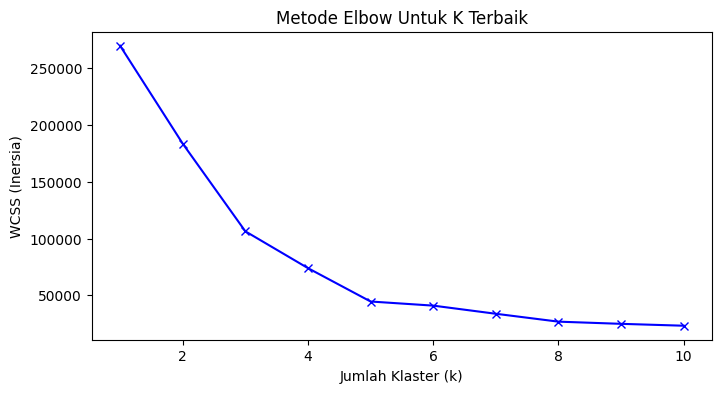

In [4]:
# 3. Buatlah model K-Means dengan mempertimbangkan jumlah k yang terbaik.
# Menggunakan Metode Elbow untuk mencari K optimal
wcss = []
K_range = range(1, 11)
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42)
    kmeans_temp.fit(X_mall)
    wcss.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, wcss, 'bx-')
plt.title('Metode Elbow Untuk K Terbaik')
plt.xlabel('Jumlah Klaster (k)')
plt.ylabel('WCSS (Inersia)')
plt.show()
# Dari grafik yang muncul, biasanya "siku" patahan terdalam ada di k=5

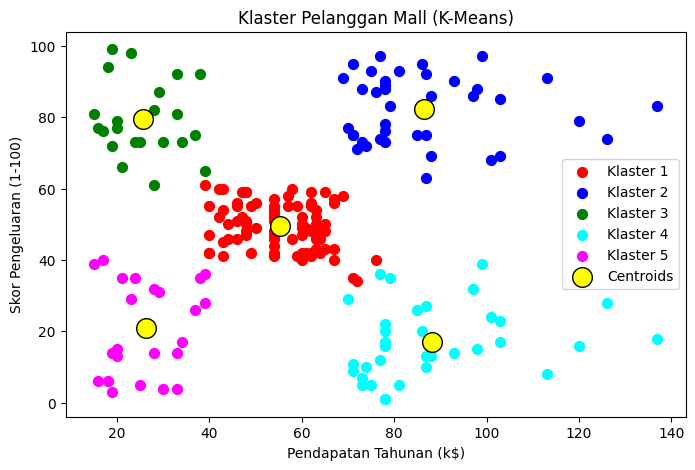

In [5]:
# Berdasarkan plot elbow, nilai k terbaik adalah 5
k_terbaik = 5
kmeans = KMeans(n_clusters=k_terbaik, random_state=42)
y_kmeans = kmeans.fit_predict(X_mall)

# Visualisasi hasil klasterisasi
plt.figure(figsize=(8, 5))
colors = ['red', 'blue', 'green', 'cyan', 'magenta']
for i in range(k_terbaik):
    plt.scatter(X_mall[y_kmeans == i, 0], X_mall[y_kmeans == i, 1],
                s=50, c=colors[i], label=f'Klaster {i+1}')

# Plot Centroid
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, c='yellow', label='Centroids', edgecolor='black')
plt.title('Klaster Pelanggan Mall (K-Means)')
plt.xlabel('Pendapatan Tahunan (k$)')
plt.ylabel('Skor Pengeluaran (1-100)')
plt.legend()
plt.show()

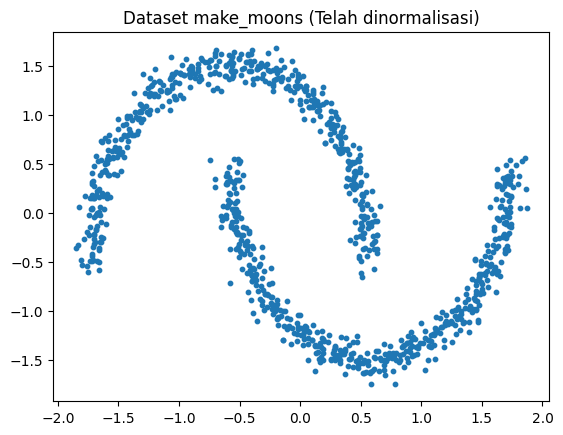

In [6]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

# 1. Buat dataset make_moons (1000 sampel, noise=0.05), lalu normalisasi.
X_moons, y_true_moons = make_moons(n_samples=1000, noise=0.05, random_state=42)
X_moons_scaled = StandardScaler().fit_transform(X_moons)

plt.scatter(X_moons_scaled[:, 0], X_moons_scaled[:, 1], s=10)
plt.title("Dataset make_moons (Telah dinormalisasi)")
plt.show()

In [7]:
from sklearn.cluster import DBSCAN
from sklearn import metrics

# 2. Jalankan DBSCAN dengan eps=0.2, min_samples=5
db = DBSCAN(eps=0.2, min_samples=5).fit(X_moons_scaled)
labels_db = db.labels_

# Hitung jumlah klaster & noise
n_clusters_ = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise_ = list(labels_db).count(-1)

print(f"Jumlah Klaster: {n_clusters_}")
print(f"Jumlah Titik Noise: {n_noise_}\n")

# 3. Evaluasi dengan metrik
print("=== Evaluasi Metrik ===")
print(f"Homogeneity: {metrics.homogeneity_score(y_true_moons, labels_db):.3f}")
print(f"Completeness: {metrics.completeness_score(y_true_moons, labels_db):.3f}")
print(f"V-measure: {metrics.v_measure_score(y_true_moons, labels_db):.3f}")
print(f"Adjusted Rand Index (ARI): {metrics.adjusted_rand_score(y_true_moons, labels_db):.3f}")
print(f"Adjusted Mutual Information (AMI): {metrics.adjusted_mutual_info_score(y_true_moons, labels_db):.3f}")
print(f"Silhouette Coefficient: {metrics.silhouette_score(X_moons_scaled, labels_db):.3f}")

Jumlah Klaster: 2
Jumlah Titik Noise: 0

=== Evaluasi Metrik ===
Homogeneity: 1.000
Completeness: 1.000
V-measure: 1.000
Adjusted Rand Index (ARI): 1.000
Adjusted Mutual Information (AMI): 1.000
Silhouette Coefficient: 0.391


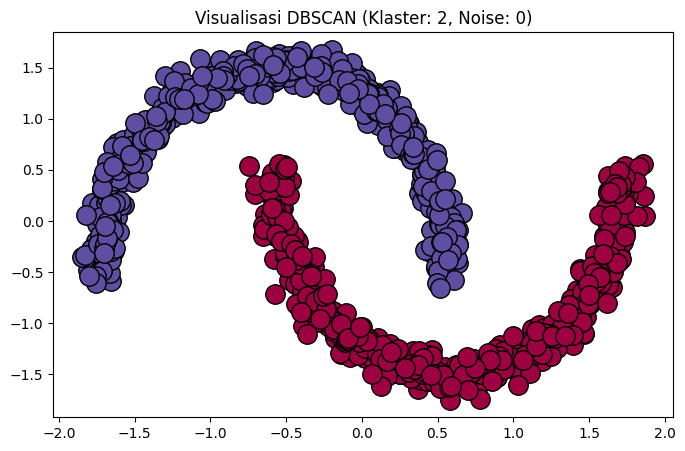

In [8]:
# 4. Visualisasikan hasil DBSCAN (core sample = besar, non-core = kecil, noise = hitam)
unique_labels = set(labels_db)
core_samples_mask = np.zeros_like(labels_db, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
plt.figure(figsize=(8, 5))

for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1] # Noise warna hitam

    class_member_mask = (labels_db == k)

    # Plot core samples (Titik besar)
    xy = X_moons_scaled[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], "o", markerfacecolor=tuple(col),
             markeredgecolor="k", markersize=14)

    # Plot non-core samples (Titik kecil)
    xy = X_moons_scaled[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], "o", markerfacecolor=tuple(col),
             markeredgecolor="k", markersize=6)

plt.title(f"Visualisasi DBSCAN (Klaster: {n_clusters_}, Noise: {n_noise_})")
plt.show()